<a href="https://colab.research.google.com/github/aum1107/MINOR-PROJECT/blob/main/feild.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Generate sample crop dataset
np.random.seed(42)

df = pd.DataFrame({
    "Soil_pH": np.random.uniform(5.5, 8.0, 1000),
    "Rainfall": np.random.uniform(50, 300, 1000),
    "Temperature": np.random.uniform(15, 40, 1000),
    "Fertilizer": np.random.uniform(20, 150, 1000),
    "Humidity": np.random.uniform(40, 90, 1000)
})

# Simulated Yield
df["Yield"] = (
    0.3 * df["Rainfall"] +
    2 * df["Soil_pH"] -
    0.5 * df["Temperature"] +
    0.4 * df["Fertilizer"] +
    0.2 * df["Humidity"]
) / 20

# Features and Target
X = df.drop("Yield", axis=1)
y = df["Yield"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))

# Prediction
sample = pd.DataFrame({
    "Soil_pH":[6.8],
    "Rainfall":[130],
    "Temperature":[29],
    "Fertilizer":[55],
    "Humidity":[72]
})

pred = model.predict(sample)
print("Predicted Yield:", round(pred[0], 2))

R² Score: 0.9787809788377355
Predicted Yield: 3.81


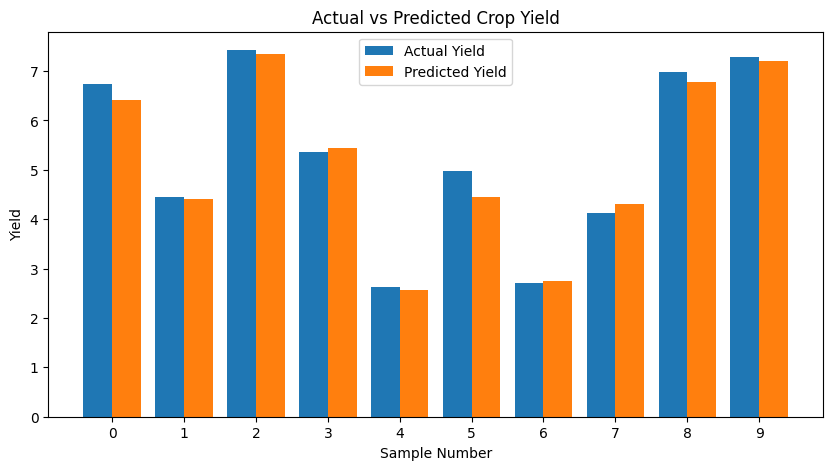

In [ ]:
import matplotlib.pyplot as plt

# First 10 samples
n = 10

plt.figure(figsize=(10,5))
x = np.arange(n)

plt.bar(x - 0.2, y_test.iloc[:n], width=0.4, label='Actual Yield')
plt.bar(x + 0.2, y_pred[:n], width=0.4, label='Predicted Yield')

plt.xlabel("Sample Number")
plt.ylabel("Yield")
plt.title("Actual vs Predicted Crop Yield")
plt.xticks(x)
plt.legend()
plt.show()